# Mass Balance — GRACE-aligned (NE mascon block)

Monthly water budget over the single JPL mascon block that holds most of the
Okavango Delta (NE quadrant, ~61 % of the delta polygon).

$$Q_{in} + P - ET - \Delta S = Q_{out} + G \;(\text{residual})$$

All spatial reductions (ET, CHIRPS, GRACE) use the same block footprint.  The
pipeline lives in `src/` (`grace_blocks`, `et_products`, `precip`, `discharge`,
`balance`, `lateral_flux`, `balance_plots`); this notebook only chooses the
geometry and calls it.

## 1 — Setup

In [30]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import IFrame, display

from src.gee_utils import ee_init
from src.grace_blocks import (discover_blocks, describe, neighbour_block, block_area_m2,
                              blocks_union, gdf_union, block_tws, domain_tws, tws_difference,
                              ee_geometry, block_map)
from src.et_products import compute_et_products, et_wide, summarize
from src.precip import compute_chirps
from src.discharge import load_mohembo_monthly
from src.balance import assemble_balance, monthly_climatology, write_outputs
from src.lateral_flux import per_model_fits, summarize_fits
from src import balance_plots as bp

# ── Paths ──
DELTA_SHP = Path("../data/regions/Delta_UCB_WGS84/Delta_UCB_WGS84.shp")
GRACE_NC  = Path("../data/grace_subsaharan_out/"
                 "GRCTellus.JPL.200204_202507.GLO.RL06.3M.MSCNv04CRI.nc")

assert DELTA_SHP.exists() and GRACE_NC.exists()

# ── Time window ──
START = "2002-04-01"                      # GRACE begins April 2002
END = (pd.Timestamp.today().normalize() + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")

# ── Output ──
GEOM_TAG = "grace_1block_ne"
FIG_DIR = Path("../figures/ET comparison") / GEOM_TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Set False once the Earth Engine CSVs are cached in FIG_DIR ──
RUN_EE = True

print(f"Window : {START} → {END}")
print(f"Figures: {FIG_DIR.resolve()}")

Window : 2002-04-01 → 2026-10-01
Figures: /Users/octaviacrompton/Projects/Okavango-water-balance/figures/ET comparison/grace_1block_ne


In [31]:
gdf = gpd.read_file(DELTA_SHP).to_crs(epsg=4326)
delta_union = gdf_union(gdf)          # geopandas-version-safe union_all
centroid = delta_union.centroid
print(f"Delta bounds: {delta_union.bounds}")

Delta bounds: (21.79128644270243, -20.185785441436625, 24.033221169007163, -18.26936168824883)


## 2 — Discover GRACE mascon blocks

In [32]:
blocks = discover_blocks(GRACE_NC, ref_geom=delta_union, pad_deg=8.0)
delta_blocks = [b for b in blocks if b["intersects_ref"]]
print(f"Total mascon blocks discovered: {len(blocks)}")
print("Blocks intersecting the delta polygon:")
for b in delta_blocks:
    print(f"  {describe(b)}  frac_delta={b['frac_ref']:.1%}")

Total mascon blocks discovered: 42
Blocks intersecting the delta polygon:
  B017 (NW)  lon 19.00–22.00  lat -19.50–-16.50  36 px  frac_delta=1.6%
  B018 (NE)  lon 22.00–25.50  lat -19.50–-16.50  42 px  frac_delta=60.7%
  B024 (SW)  lon 19.50–22.50  lat -22.50–-19.50  36 px  frac_delta=4.7%
  B025 (SE)  lon 22.50–25.50  lat -22.50–-19.50  36 px  frac_delta=33.0%


In [33]:
USE_BLOCKS = [b for b in delta_blocks if b["quadrant"] == "NE"]
NE_BLOCK = USE_BLOCKS[0]
DOMAIN_LABEL = "NE block"
NW_BLOCK = neighbour_block(NE_BLOCK, blocks, "W")     # delta-adjacent NW block
SE_BLOCK = neighbour_block(NE_BLOCK, blocks, "S")
print("Domain :", describe(NE_BLOCK))
print("West   :", describe(NW_BLOCK))
print("South  :", describe(SE_BLOCK))
m = block_map(blocks, {"#1b9e77": USE_BLOCKS, "#d95f02": [NW_BLOCK, SE_BLOCK]}, ref_gdf=gdf,
              center=(centroid.y, centroid.x), zoom_start=7, ref_name="Delta polygon")
map_path = FIG_DIR / "study_area_map.html"; m.save(str(map_path))
IFrame(src=str(map_path), width=800, height=500)

Domain : B018 (NE)  lon 22.00–25.50  lat -19.50–-16.50  42 px
West   : B017 (NW)  lon 19.00–22.00  lat -19.50–-16.50  36 px
South  : B025 (SE)  lon 22.50–25.50  lat -22.50–-19.50  36 px


## 3 — Earth Engine geometry + area

In [34]:
ee_init()
block_geom = ee_geometry(USE_BLOCKS)          # one polygon per block
block_union = blocks_union(USE_BLOCKS)        # shapely, for GLEAM
block_area_m2_ = sum(block_area_m2(b) for b in USE_BLOCKS)
ee_area = float(block_geom.area(maxError=1).getInfo())
print(f"Domain area: {block_area_m2_/1e6:,.0f} km² (geodesic)   EE: {ee_area/1e6:,.0f} km²")

Domain area: 123,091 km² (geodesic)   EE: 123,485 km²


## 4 — Monthly ET over the NE block

MOD16A2GF_v61     : 285 valid months (2002-04-01 → 2025-12-01)
PML_v2_landET     : 273 valid months (2002-04-01 → 2024-12-01)
TerraClimate_aet  : 273 valid months (2002-04-01 → 2024-12-01)
FLDAS_Evap        : 293 valid months (2002-04-01 → 2026-08-01)
ERA5Land_totalET  : 293 valid months (2002-04-01 → 2026-08-01)
USGS_SSEBop       : 233 valid months (2003-01-01 → 2022-05-01)
WaPORv3_AETI      : 104 valid months (2018-01-01 → 2026-08-01)
GLEAM_v42a        : 273 valid months
Saved: ../figures/ET comparison/grace_1block_ne/et_monthly.csv  (2131 rows)


,first,last,n,mean_mm,coverage
dataset,,,,,
ERA5Land_totalET,2002-04-01,2026-08-01,293,55.7,1.00
FLDAS_Evap,2002-04-01,2026-08-01,293,48.7,1.00
GLEAM_v42a,2002-04-01,2024-12-01,273,53.1,1.00
MOD16A2GF_v61,2002-04-01,2025-12-01,285,36.6,0.96
PML_v2_landET,2002-04-01,2024-12-01,273,63.5,1.00
TerraClimate_aet,2002-04-01,2024-12-01,273,45.4,1.00
USGS_SSEBop,2003-01-01,2022-05-01,233,60.2,1.00
WaPORv3_AETI,2018-01-01,2026-08-01,104,68.5,1.00


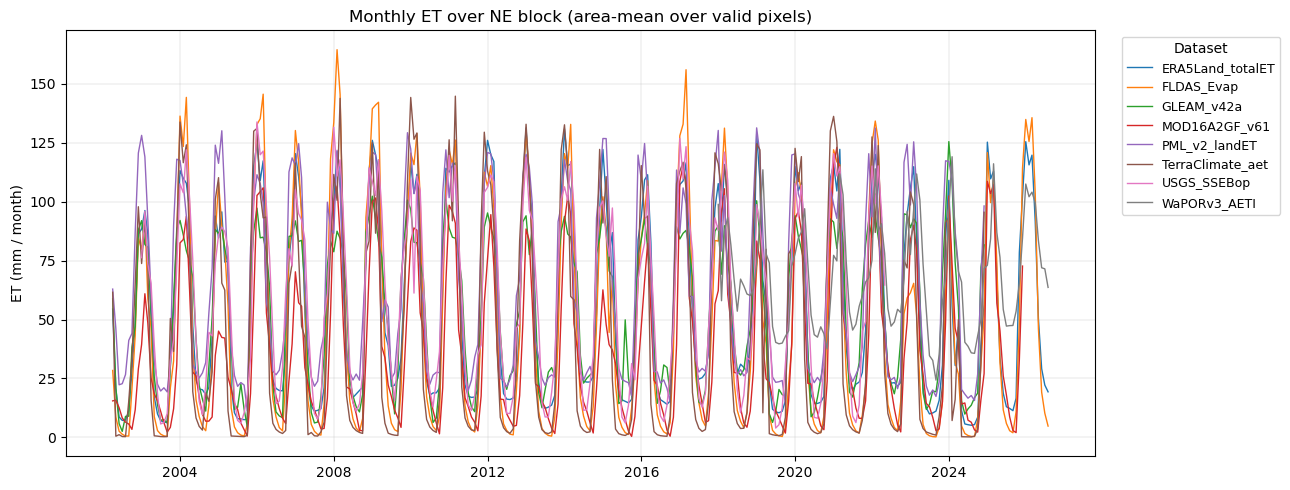

In [35]:
df_et = compute_et_products(block_geom, block_area_m2_, START, END,
                            csv_path=FIG_DIR / "et_monthly.csv", run=RUN_EE,
                            gleam_geom=block_union)
display(summarize(df_et))
et_mm_wide = et_wide(df_et, "et_mm_mean")
bp.plot_et_products(et_mm_wide, f"Monthly ET over {DOMAIN_LABEL} (area-mean over valid pixels)",
                    save=FIG_DIR / "et_products.png")
plt.show()

## ET diagnostic — delta polygon vs GRACE domain

The same products over the **delta polygon**, for comparison with the mascon
domain.  Large differences mean the products respond to wetland conditions.

MOD16A2GF_v61     : 285 valid months (2002-04-01 → 2025-12-01)
PML_v2_landET     : 273 valid months (2002-04-01 → 2024-12-01)
TerraClimate_aet  : 273 valid months (2002-04-01 → 2024-12-01)
FLDAS_Evap        : 293 valid months (2002-04-01 → 2026-08-01)
ERA5Land_totalET  : 293 valid months (2002-04-01 → 2026-08-01)
USGS_SSEBop       : 233 valid months (2003-01-01 → 2022-05-01)
WaPORv3_AETI      : 104 valid months (2018-01-01 → 2026-08-01)
GLEAM_v42a        : 273 valid months
Saved: ../figures/ET comparison/grace_1block_ne/et_monthly_delta_poly.csv  (2131 rows)


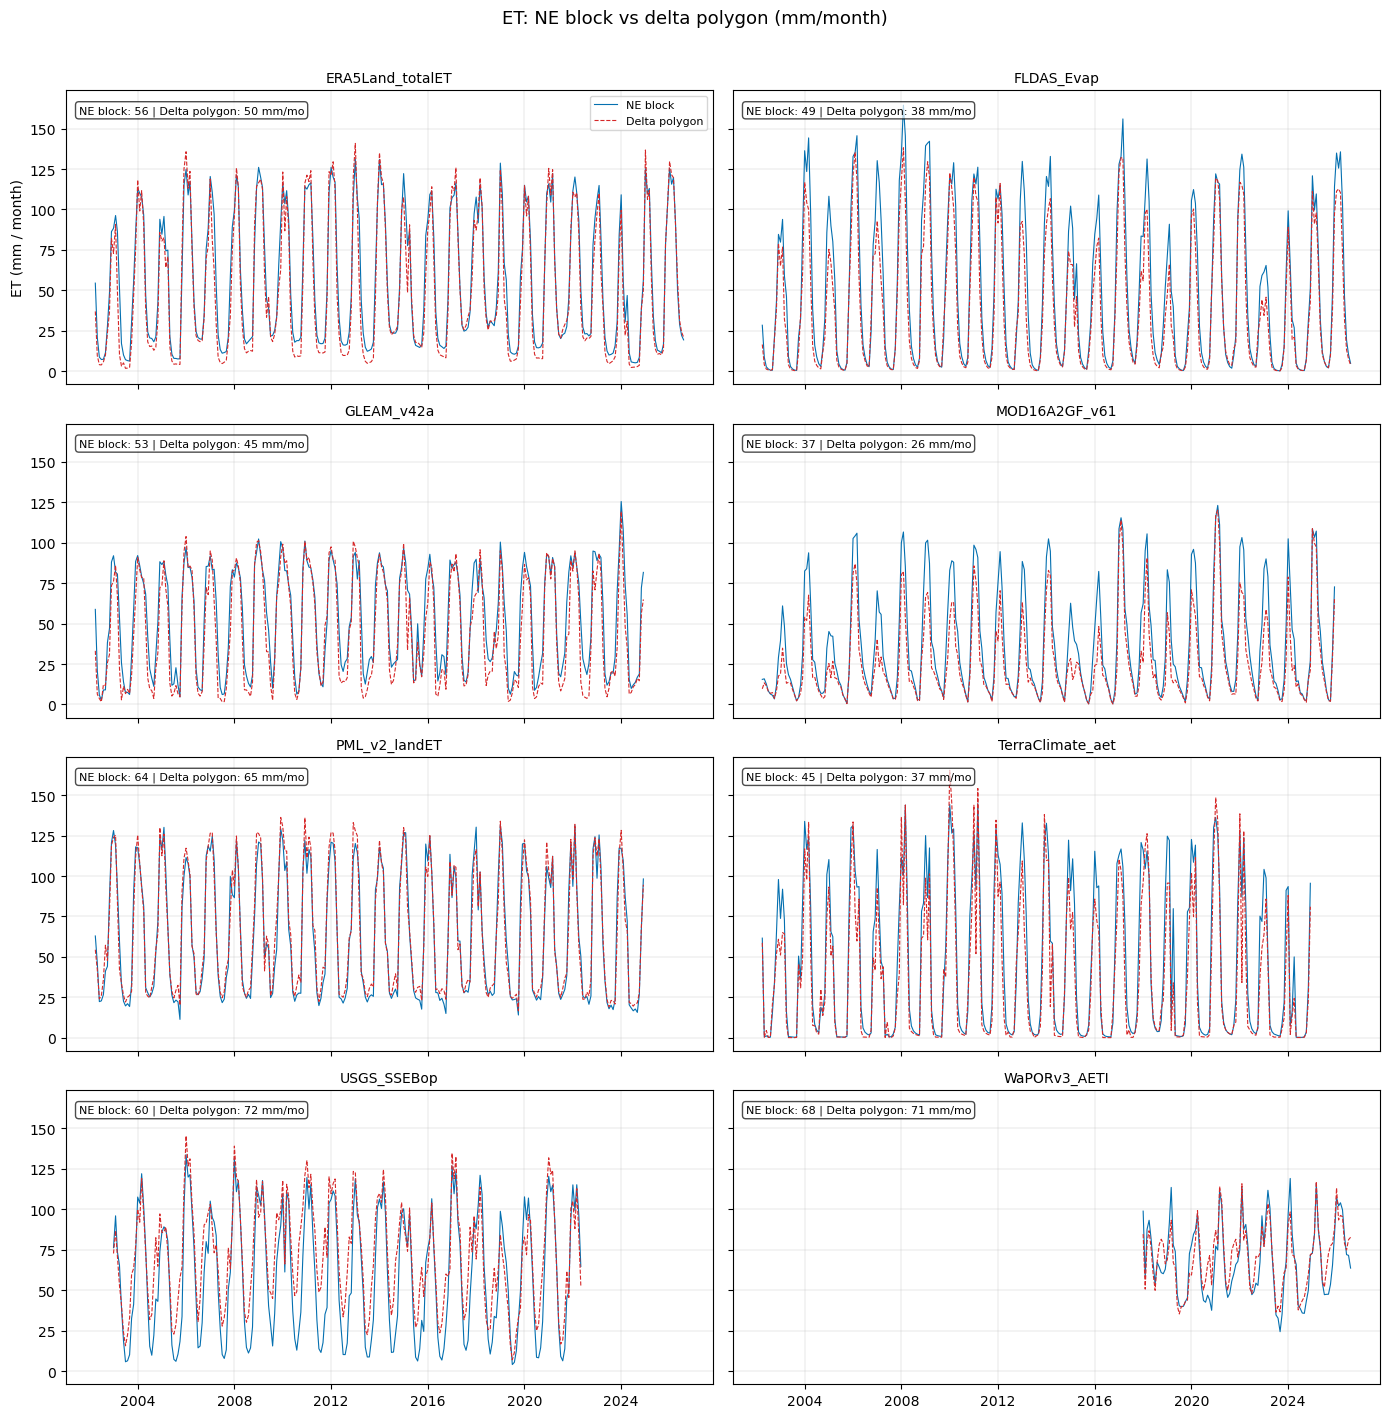

In [36]:
delta_geom_ee = ee_geometry(delta_union)
delta_area_m2 = block_area_m2(delta_union)
df_et_delta = compute_et_products(delta_geom_ee, delta_area_m2, START, END,
                                  csv_path=FIG_DIR / "et_monthly_delta_poly.csv", run=RUN_EE,
                                  gleam_geom=delta_union)
bp.plot_et_two_domains(et_mm_wide, et_wide(df_et_delta, "et_mm_mean"), DOMAIN_LABEL, "Delta polygon",
                       f"ET: {DOMAIN_LABEL} vs delta polygon (mm/month)",
                       save=FIG_DIR / "et_delta_vs_grace_domain.png")
plt.show()

## 5 — CHIRPS precipitation

In [37]:
df_chirps = compute_chirps(block_geom, block_area_m2_, START, END,
                           csv_path=FIG_DIR / "chirps_monthly.csv", run=RUN_EE)

CHIRPS: 293 valid months (2002-04-01 → 2026-08-01)
Saved: ../figures/ET comparison/grace_1block_ne/chirps_monthly.csv  (294 rows)


## GRACE TWS over the domain

Block TWS comes from the **local JPL netCDF** (all pixels in a mascon share one
series), labelled by the midpoint of each solution's `time_bounds`.  The earlier
Earth Engine reduction labelled solutions by the day before their period and
put ~90 % of months one month early.

GRACE solutions: 246  (2002-04-01 → 2025-07-01)


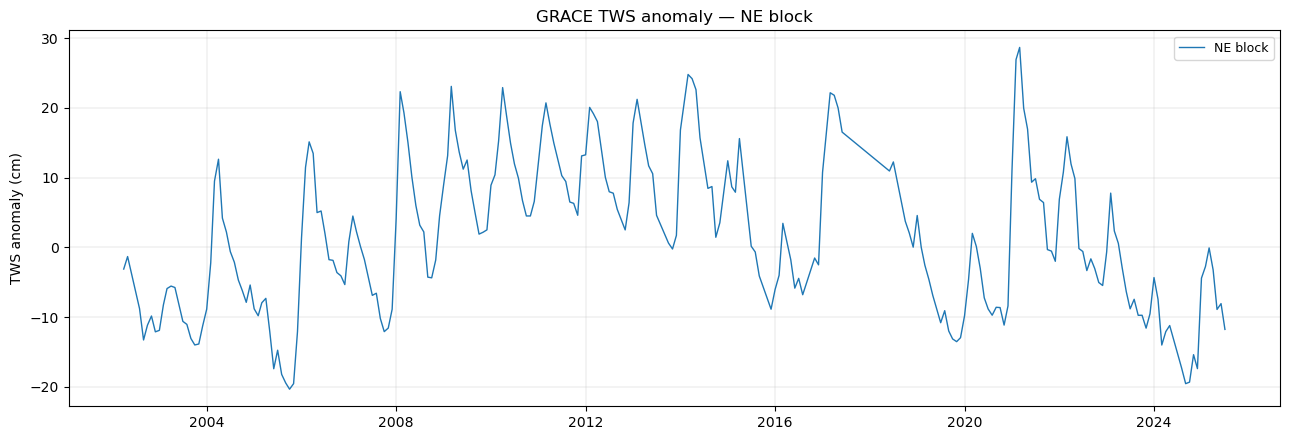

In [38]:
df_tws = domain_tws(GRACE_NC, USE_BLOCKS)
df_tws.to_csv(FIG_DIR / "grace_monthly.csv")
print(f"GRACE solutions: {len(df_tws)}  ({df_tws.index.min().date()} → {df_tws.index.max().date()})")
bp.plot_tws_series({DOMAIN_LABEL: df_tws["TWS_cm"]}, f"GRACE TWS anomaly — {DOMAIN_LABEL}")
plt.show()

### Adjacent-block TWS differences (lateral-flux proxies)

NW − NE: mean +2.83 cm, std 5.22 cm


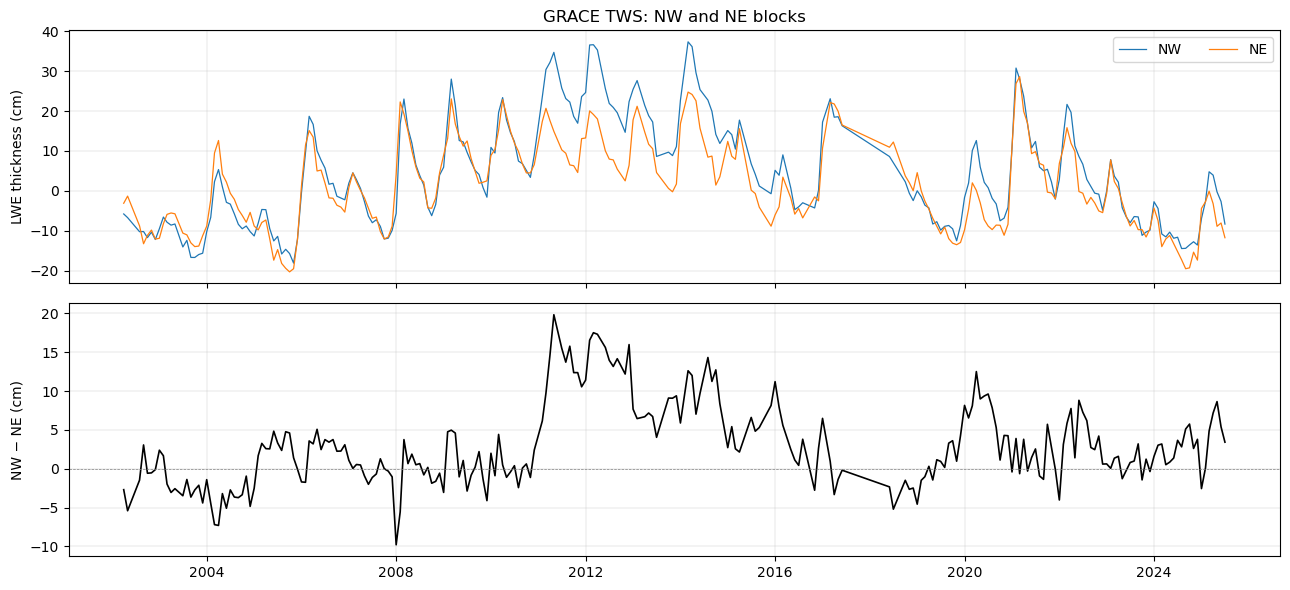

NE − SE: mean +1.43 cm, std 8.74 cm


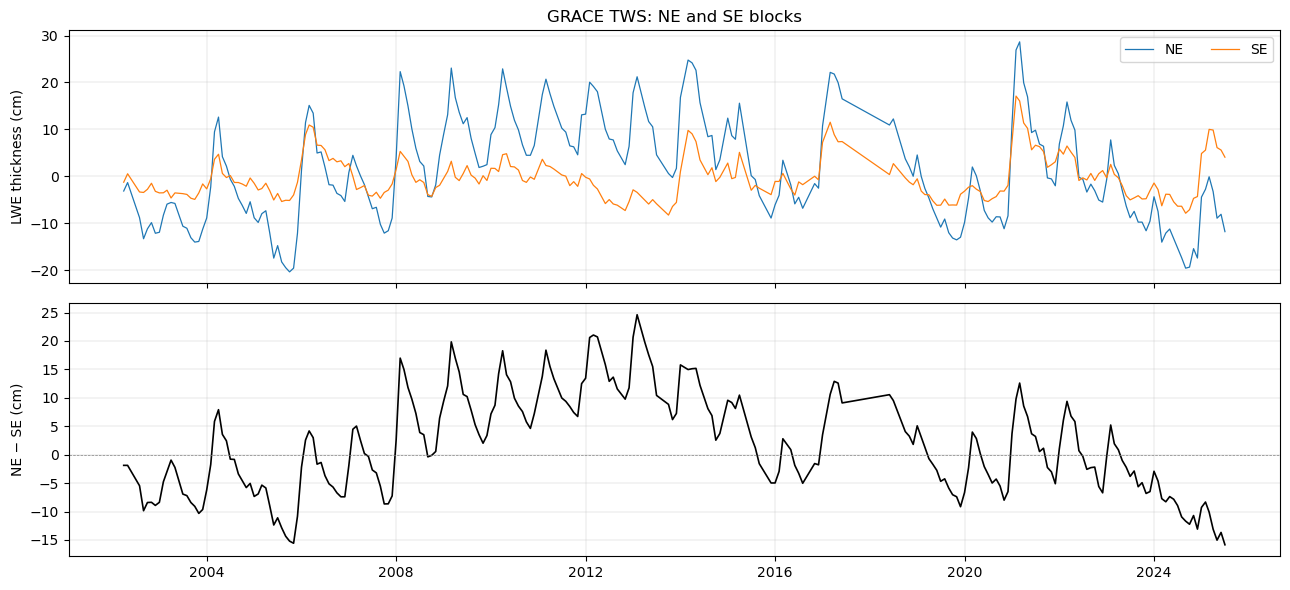

In [39]:
df_nw_ne = tws_difference(GRACE_NC, NW_BLOCK, NE_BLOCK, "NW_NE_diff_cm")
df_ne_se = tws_difference(GRACE_NC, NE_BLOCK, SE_BLOCK, "NE_SE_diff_cm")
bp.plot_tws_pair(df_nw_ne, df_nw_ne.columns[0], df_nw_ne.columns[1], "NW_NE_diff_cm", "NW", "NE",
                 "GRACE TWS: NW and NE blocks"); plt.show()
bp.plot_tws_pair(df_ne_se, df_ne_se.columns[0], df_ne_se.columns[1], "NE_SE_diff_cm", "NE", "SE",
                 "GRACE TWS: NE and SE blocks"); plt.show()

## 7 — Mohembo inflow

Mohembo: 591 months (1974-12-01 → 2024-02-01), gap-filled 4


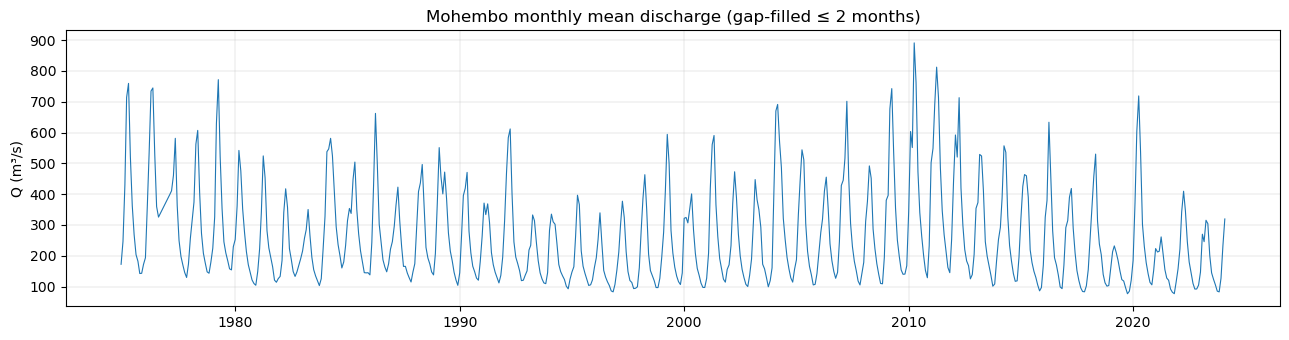

In [40]:
q_mohembo = load_mohembo_monthly(block_area_m2_)
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(q_mohembo["date"], q_mohembo["Qin_m3s"], lw=0.8)
ax.set_title("Mohembo monthly mean discharge (gap-filled ≤ 2 months)")
ax.set_ylabel("Q (m³/s)")
ax.grid(True, lw=0.2)
plt.tight_layout(); plt.show()

## Mass-balance assembly

All terms are placed on a continuous month-start grid.  ΔS uses a **centred
difference** `(S[t+1] − S[t−1]) / 2`, because a GRACE solution is the mean state
of its month while P, ET and Q are month totals.  A single missing GRACE month is
linearly interpolated before differencing (`fill_tws_gap_months=1`); longer
gaps, including the 11-month GRACE/GRACE-FO gap, are never bridged.  In the
ΔS panel, hollow markers show months whose ΔS depends on an interpolated
month.  ET is the median of the available products each month.

In [41]:
bal = assemble_balance(df_et, df_chirps, df_tws, block_area_m2_,
                       qin=q_mohembo,
                       extra={"NW_NE_diff_cm": df_nw_ne["NW_NE_diff_cm"], "NE_SE_diff_cm": df_ne_se["NE_SE_diff_cm"]},
                       start=START, ds_scheme="centered",
                       fill_tws_gap_months=1)       # interpolate single missing GRACE months
df_balance = bal.df
print(bal.summary())
print("\nResidual = Qin + P − ET − ΔS  (= Qout + G)")
df_balance.tail(6)

TypeError: assemble_balance() got an unexpected keyword argument 'fill_tws_gap_months'

## 9 — Mass-balance plots

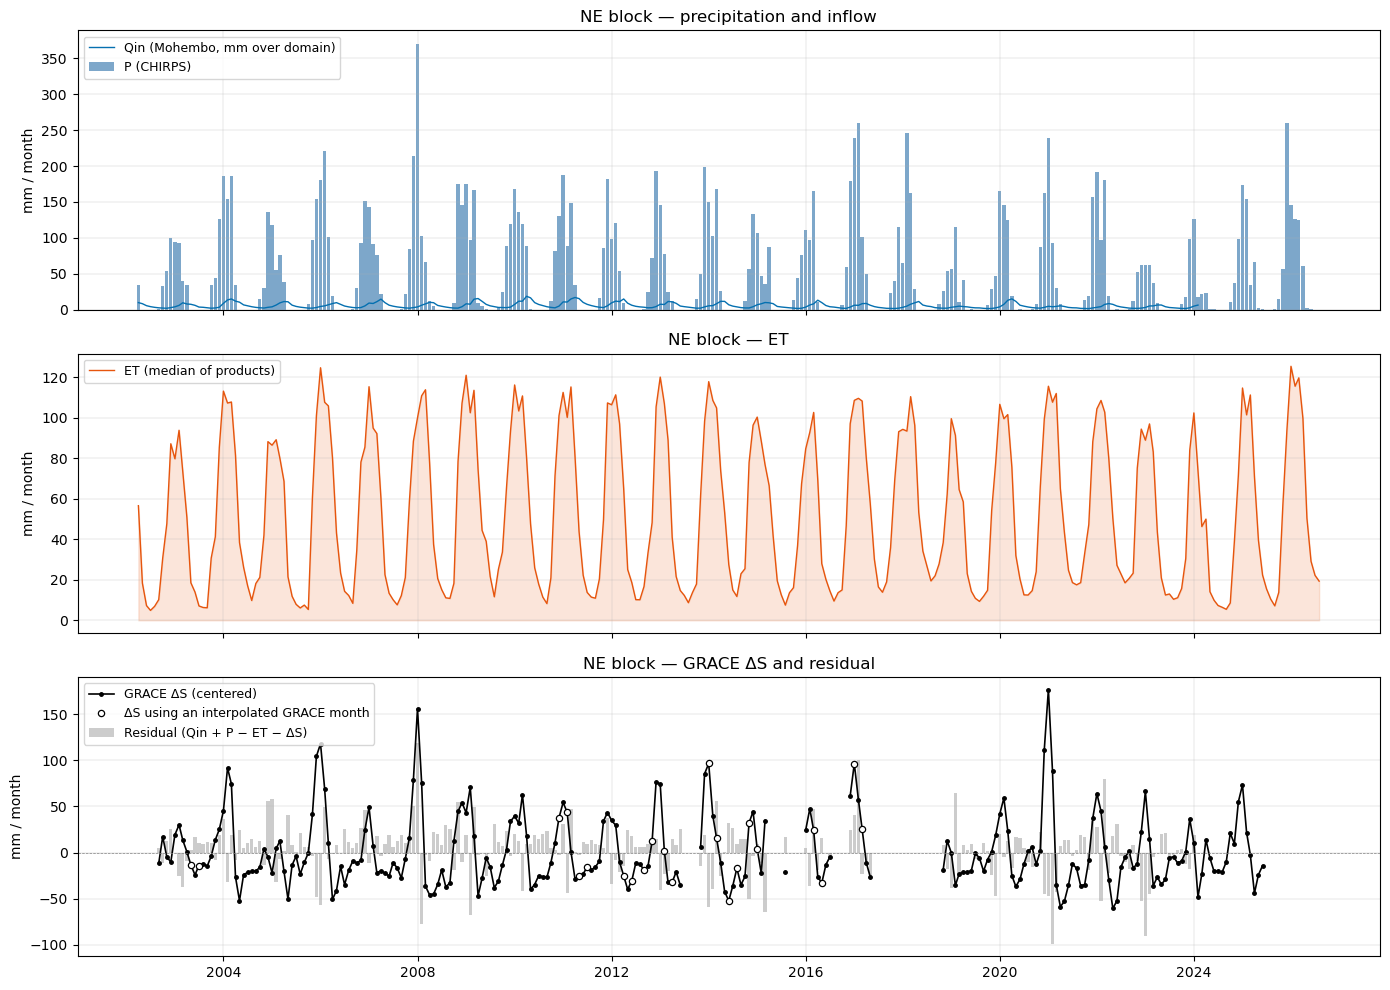

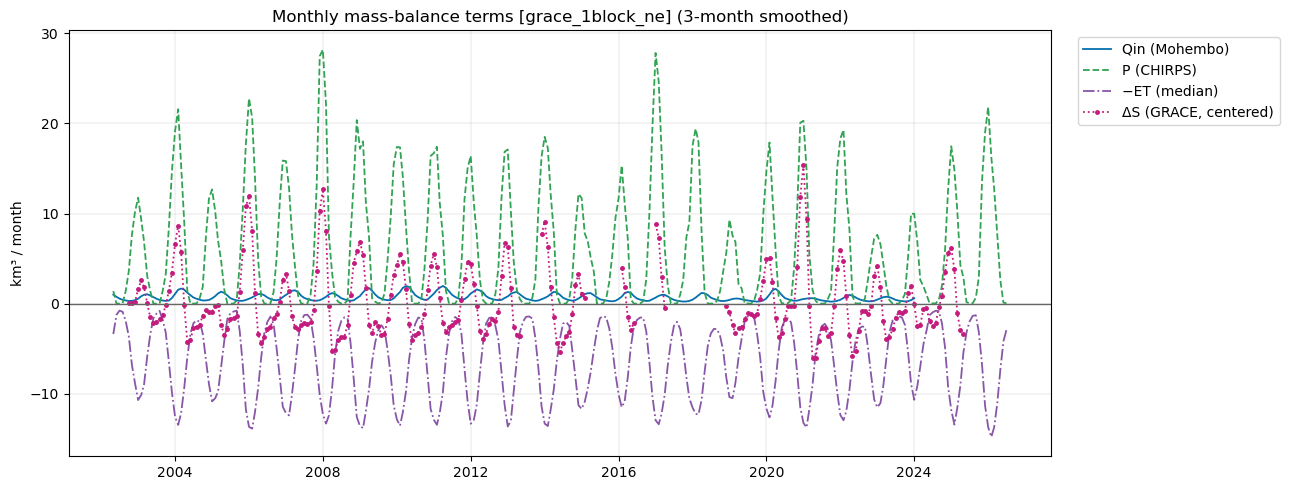

Cumulative residual over 225 closure months: +77.58 km³ (mean +0.345 km³/month)


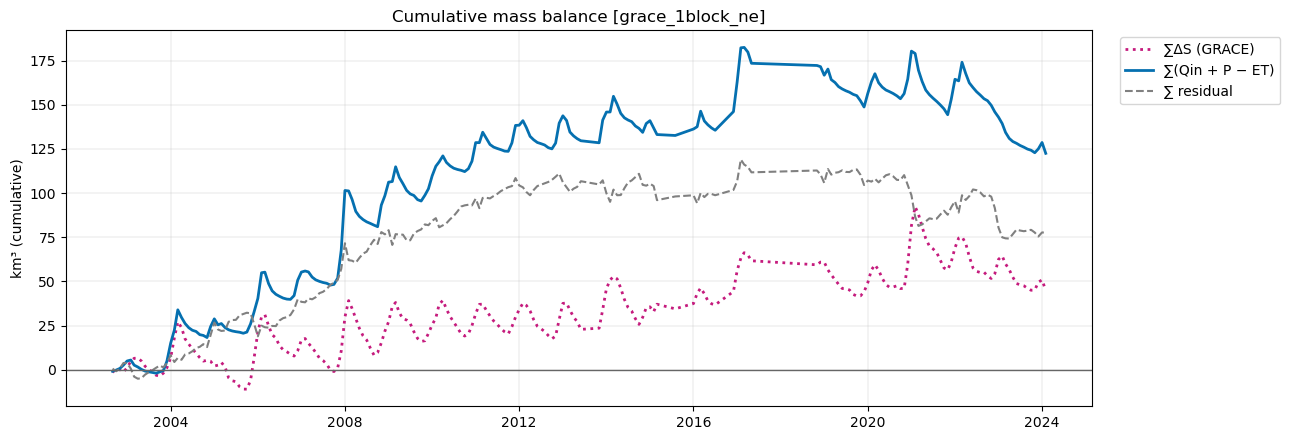

In [ ]:
bp.plot_balance_panels(bal, DOMAIN_LABEL, save=FIG_DIR / "mass_balance_panels.png"); plt.show()
bp.plot_terms(bal, f"Monthly mass-balance terms [{GEOM_TAG}]", save=FIG_DIR / "mass_balance_terms.png"); plt.show()
bp.plot_cumulative(bal, f"Cumulative mass balance [{GEOM_TAG}]", save=FIG_DIR / "cumulative_sums.png"); plt.show()

## 10 — Per-ET-product diagnostics

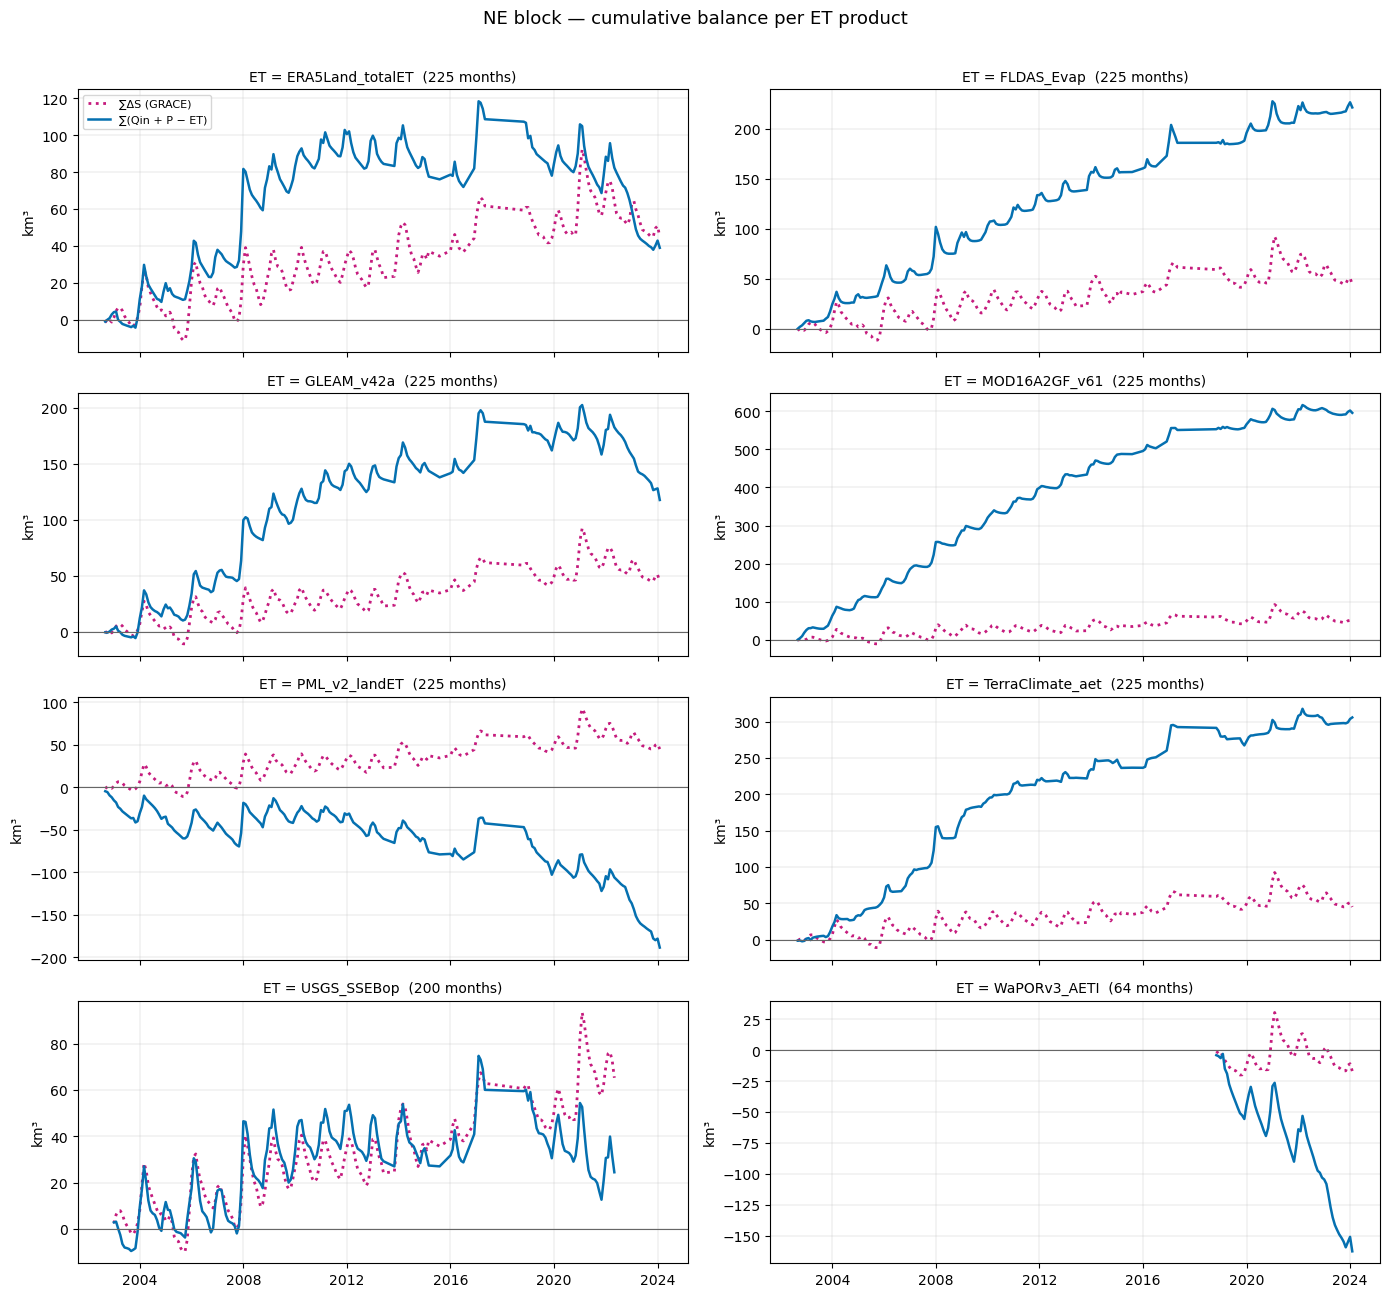

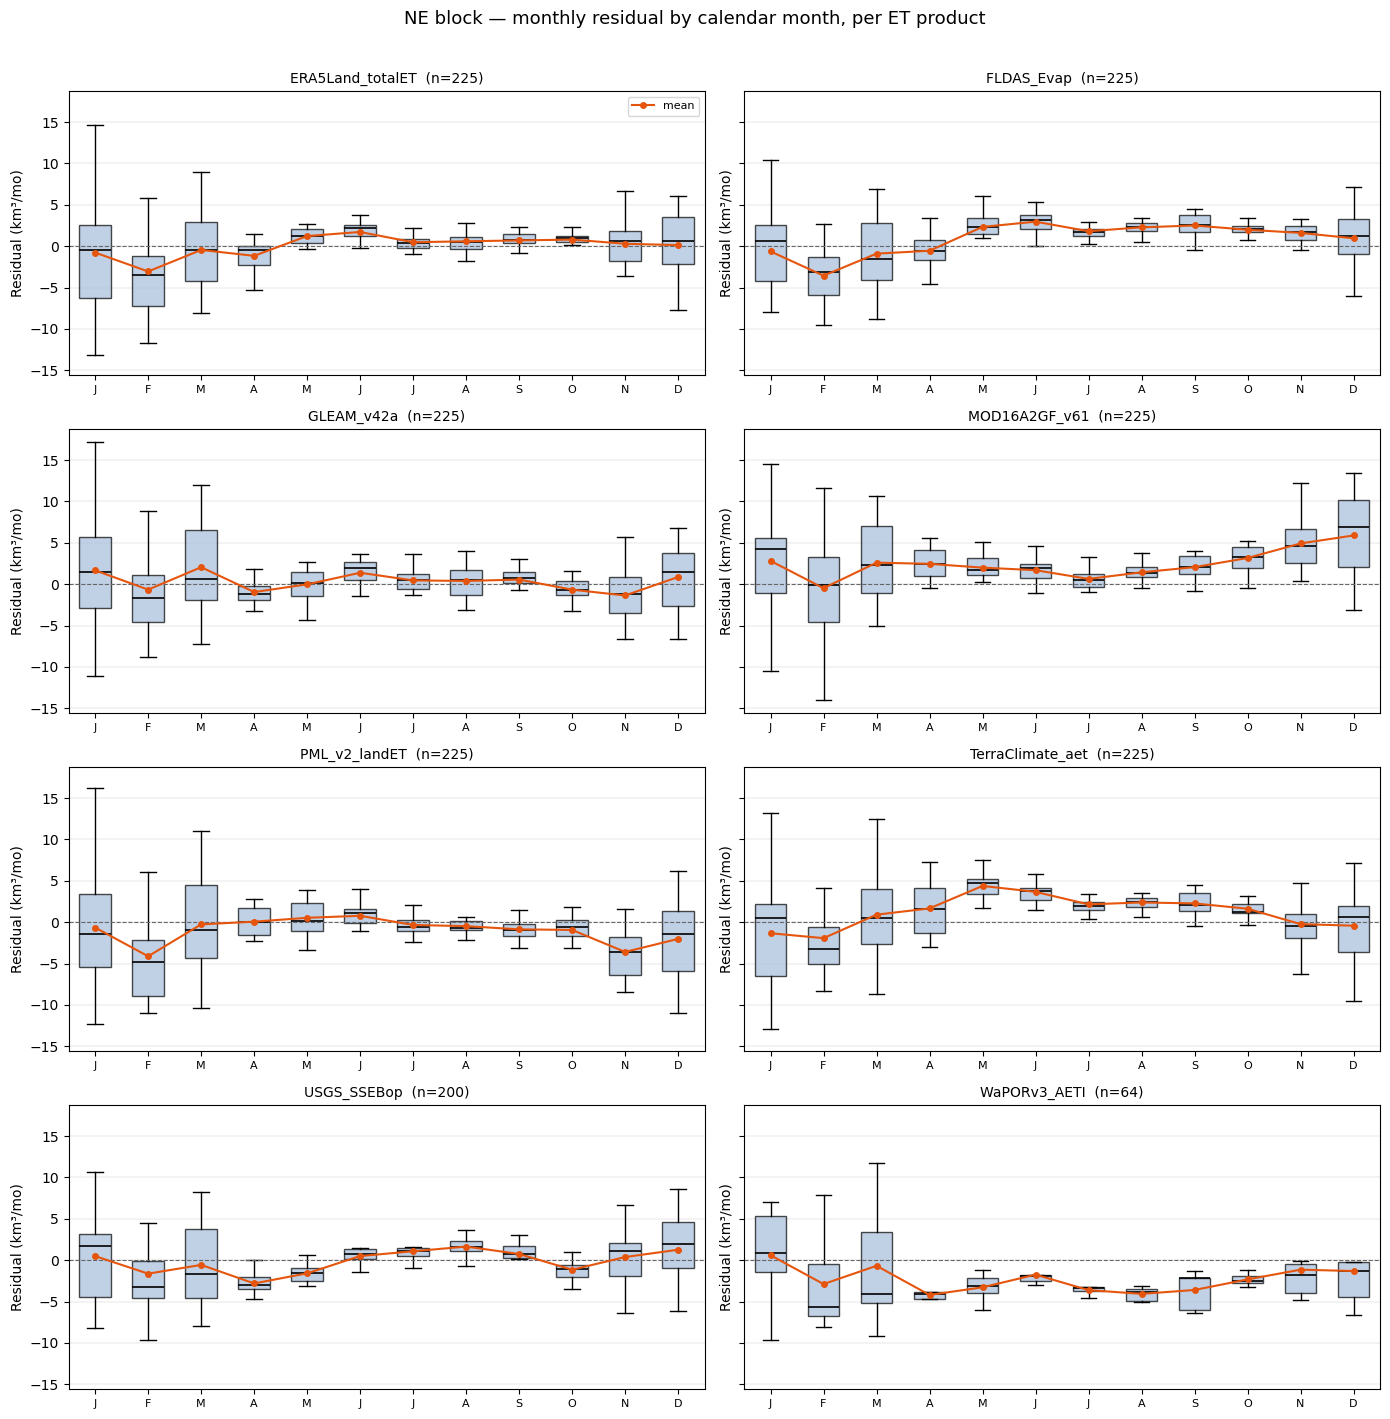

In [ ]:
bp.plot_per_model_cumulative(bal, DOMAIN_LABEL, fig_dir=FIG_DIR); plt.show()
bp.plot_monthly_divergence(bal, f"{DOMAIN_LABEL} — monthly residual by calendar month, per ET product",
                           save=FIG_DIR / "monthly_divergence_by_model.png"); plt.show()

## Tunable lateral-flux terms

$$\text{flux}_t + \sum_k \alpha_k\,x_{k,t} + c \approx \Delta S_t$$

where $x_k$ are TWS head differences between adjacent mascon blocks (cm).  The
fit is on **monthly** residuals with an intercept $c$ that absorbs a constant
ET-product bias, and the reported improvement is relative to that bias-only
null.  (The earlier version regressed cumulative residuals on cumulative head
differences; since the head differences have a non-zero mean, that regressor
is nearly a straight line and α mostly fitted each product's drift.)  A real
lateral flux should give α of the **same sign for every ET product**.

── 1-parameter: α × (S_NW − S_NE) ──
        ET_model  alpha_NW_NE_diff_cm  intercept  RMSE_null_km3  RMSE_fit_km3  improvement_pct   n
     USGS_SSEBop               0.0308     0.1762         3.5492        3.5450           0.1197 189
      FLDAS_Evap              -0.0045    -0.7149         3.6123        3.6122           0.0023 214
ERA5Land_totalET               0.0398    -0.0261         3.6510        3.6447           0.1718 214
      GLEAM_v42a               0.0277    -0.3326         3.6828        3.6798           0.0822 214
   MOD16A2GF_v61               0.0186    -2.4613         3.9217        3.9204           0.0325 214
   PML_v2_landET              -0.0120     1.1711         4.0054        4.0049           0.0129 214
    WaPORv3_AETI              -0.0428     2.3890         4.0531        4.0502           0.0727  64
TerraClimate_aet               0.0224    -1.1635         4.0967        4.0949           0.0431 214

Median RMSE improvement over bias-only null: 0.1%
  alpha_NW_NE_diff_cm

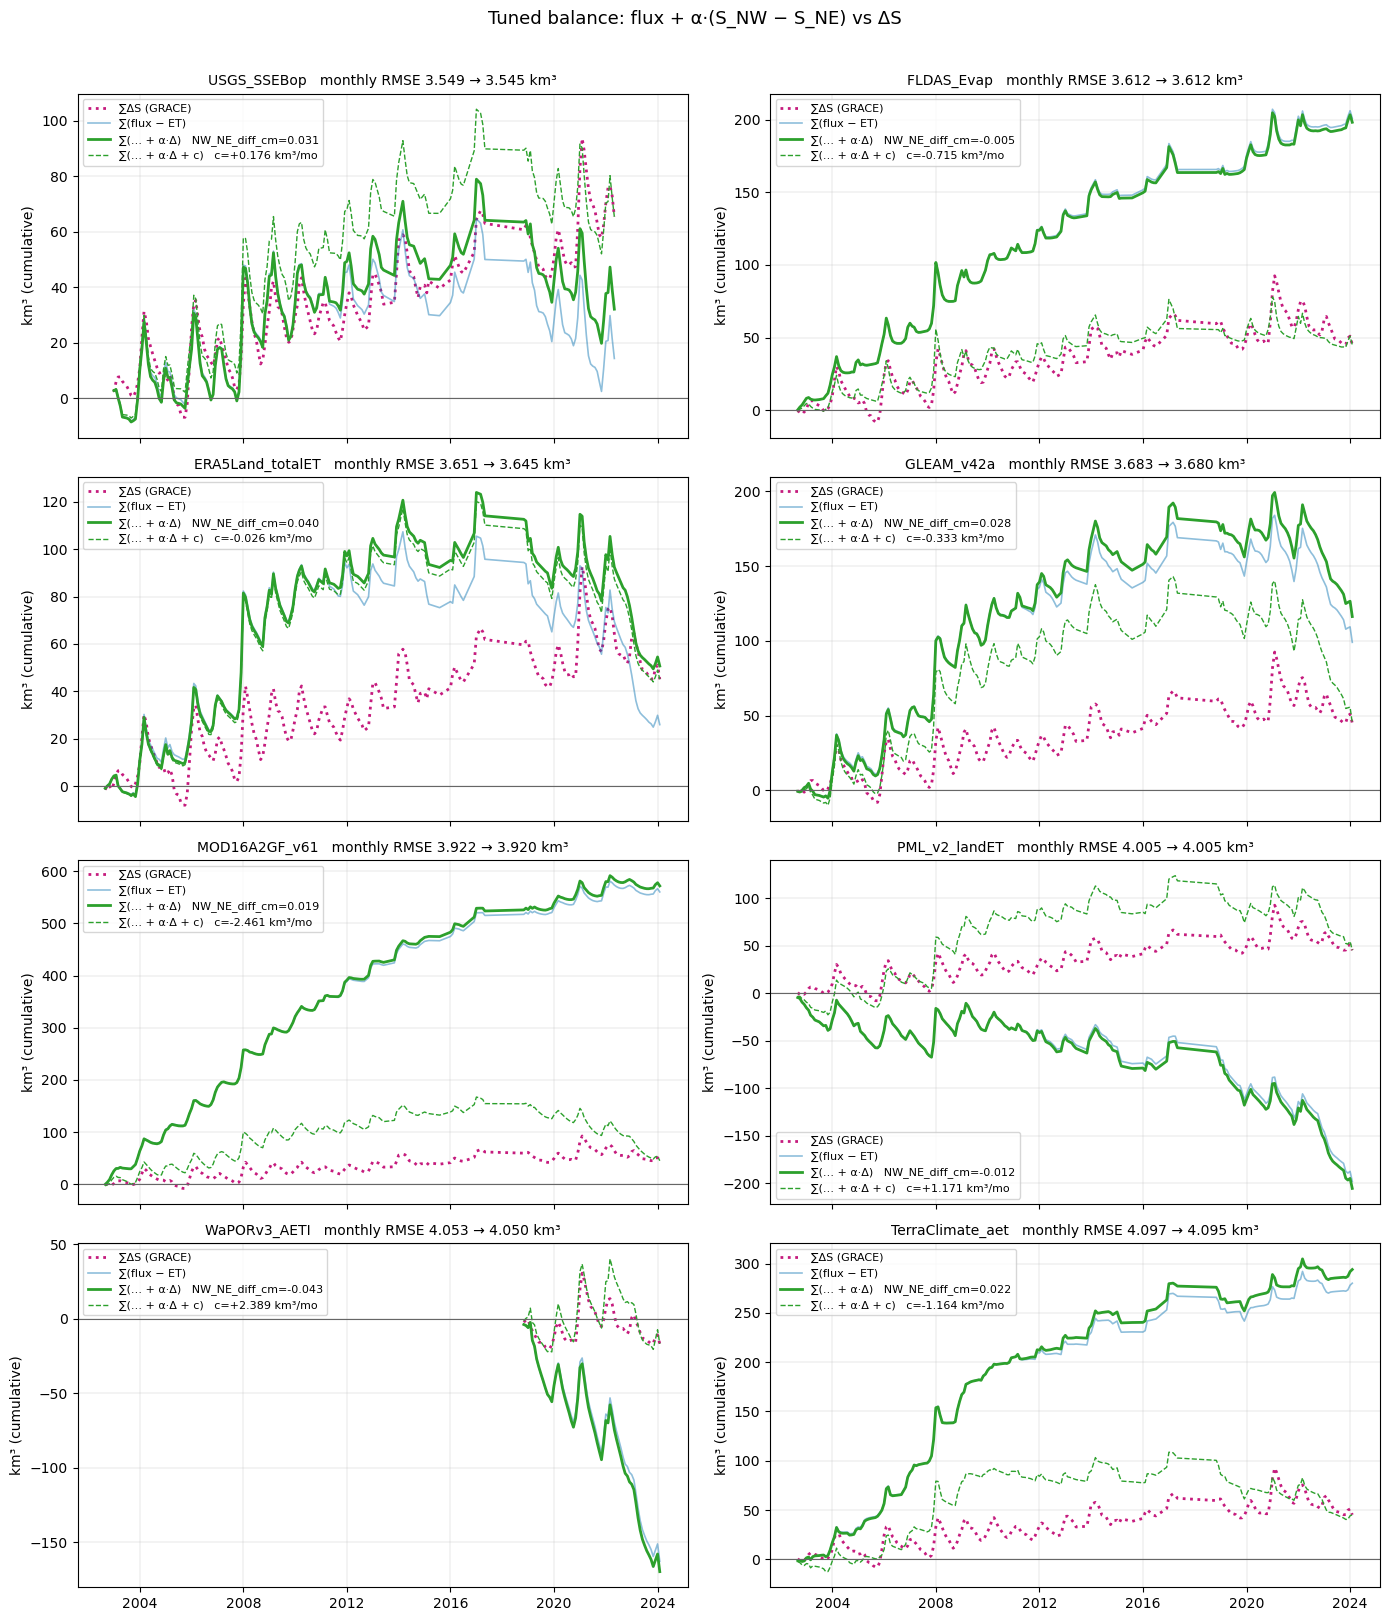

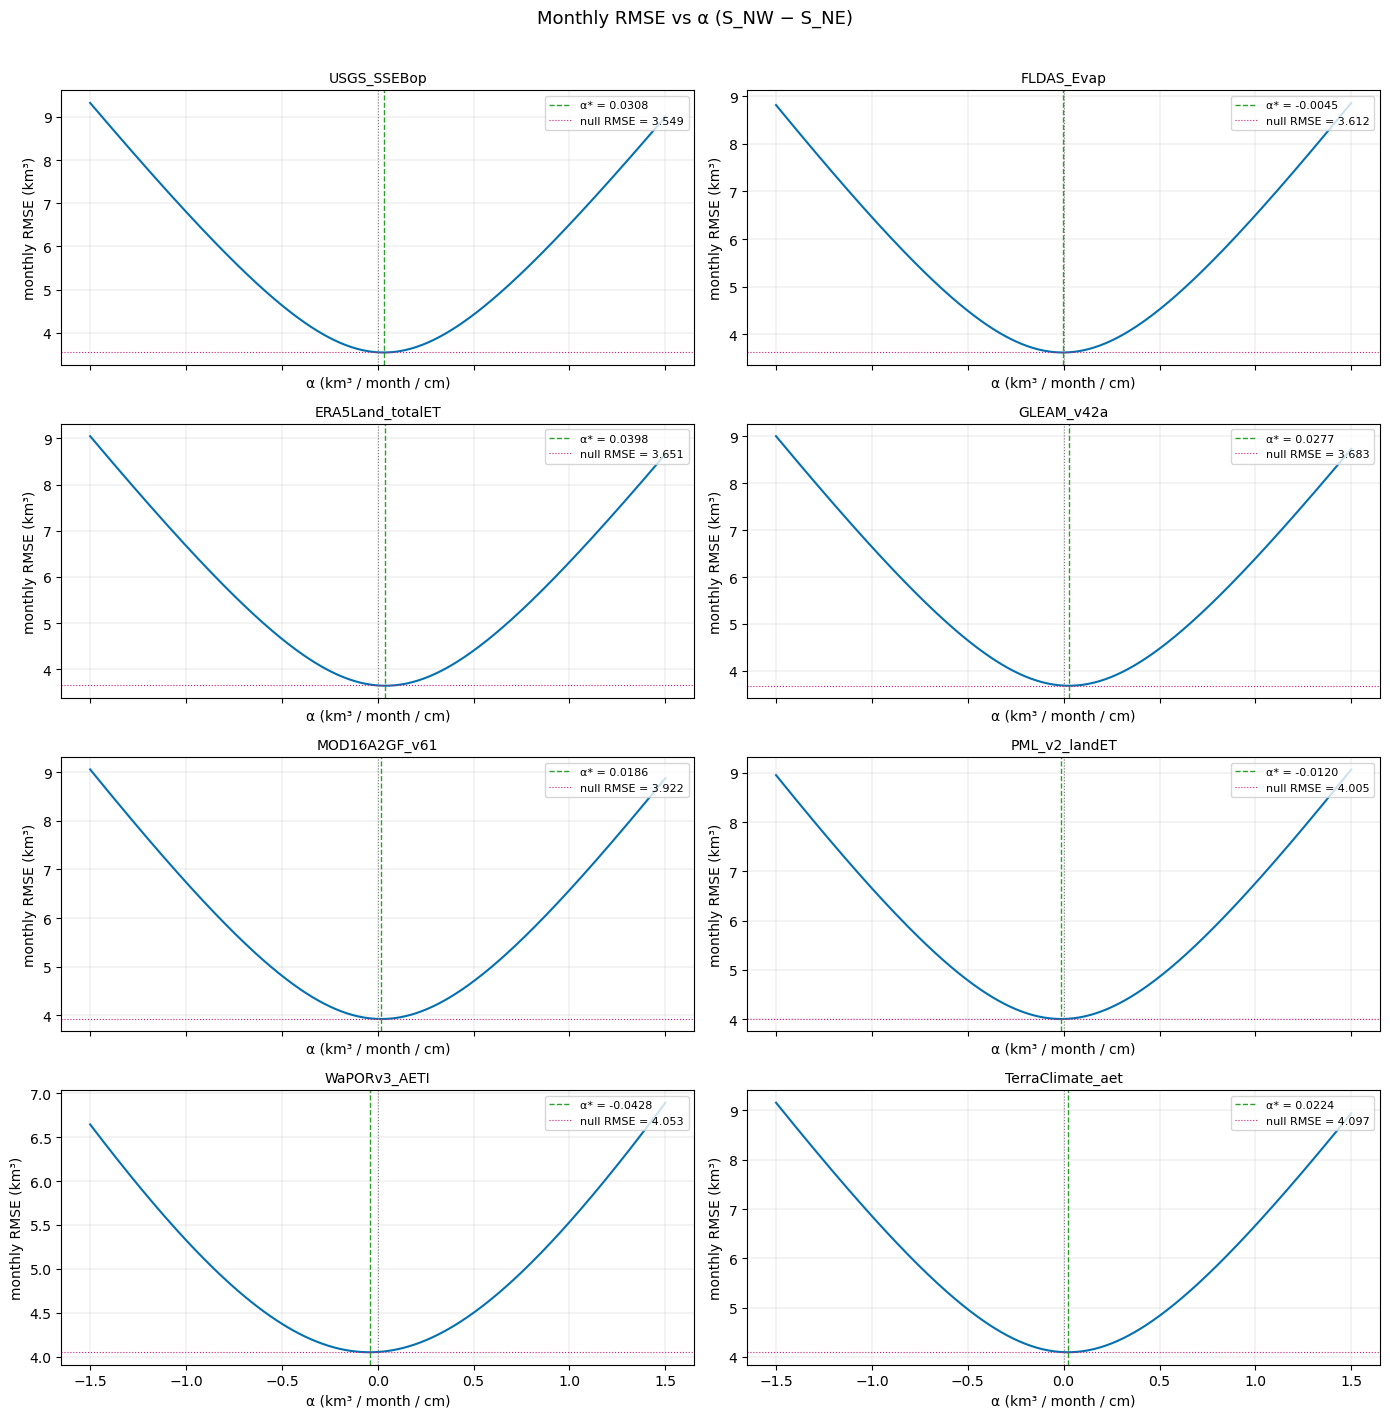

In [ ]:
results_1p, plot_1p = per_model_fits(bal, ["NW_NE_diff_cm"])
summarize_fits(results_1p, "1-parameter: α × (S_NW − S_NE)")
bp.plot_tuned_cumulative(results_1p, plot_1p, f"Tuned balance: flux + α·(S_NW − S_NE) vs ΔS",
                         save=FIG_DIR / "tuned_alpha_cumulative.png"); plt.show()
bp.plot_alpha_sensitivity(bal, results_1p, "NW_NE_diff_cm", title=f"Monthly RMSE vs α (S_NW − S_NE)",
                          save=FIG_DIR / "rmse_vs_alpha.png"); plt.show()

── 2-parameter: α × (S_NW − S_NE) + β × (S_NE − S_SE), β ≤ 0 ──
        ET_model  alpha_NW_NE_diff_cm  alpha_NE_SE_diff_cm  intercept  RMSE_null_km3  RMSE_fit_km3  improvement_pct   n
     USGS_SSEBop               0.0308              -0.0000     0.1762         3.5492        3.5450           0.1197 189
      FLDAS_Evap              -0.0045              -0.0000    -0.7149         3.6123        3.6122           0.0023 214
ERA5Land_totalET               0.0398              -0.0000    -0.0261         3.6510        3.6447           0.1718 214
      GLEAM_v42a               0.0477              -0.0333    -0.3139         3.6828        3.6706           0.3326 214
   MOD16A2GF_v61               0.0186              -0.0000    -2.4613         3.9217        3.9204           0.0325 214
   PML_v2_landET               0.0239              -0.0600     1.2047         4.0054        3.9773           0.7007 214
    WaPORv3_AETI              -0.0428              -0.0000     2.3890         4.0531        4.05

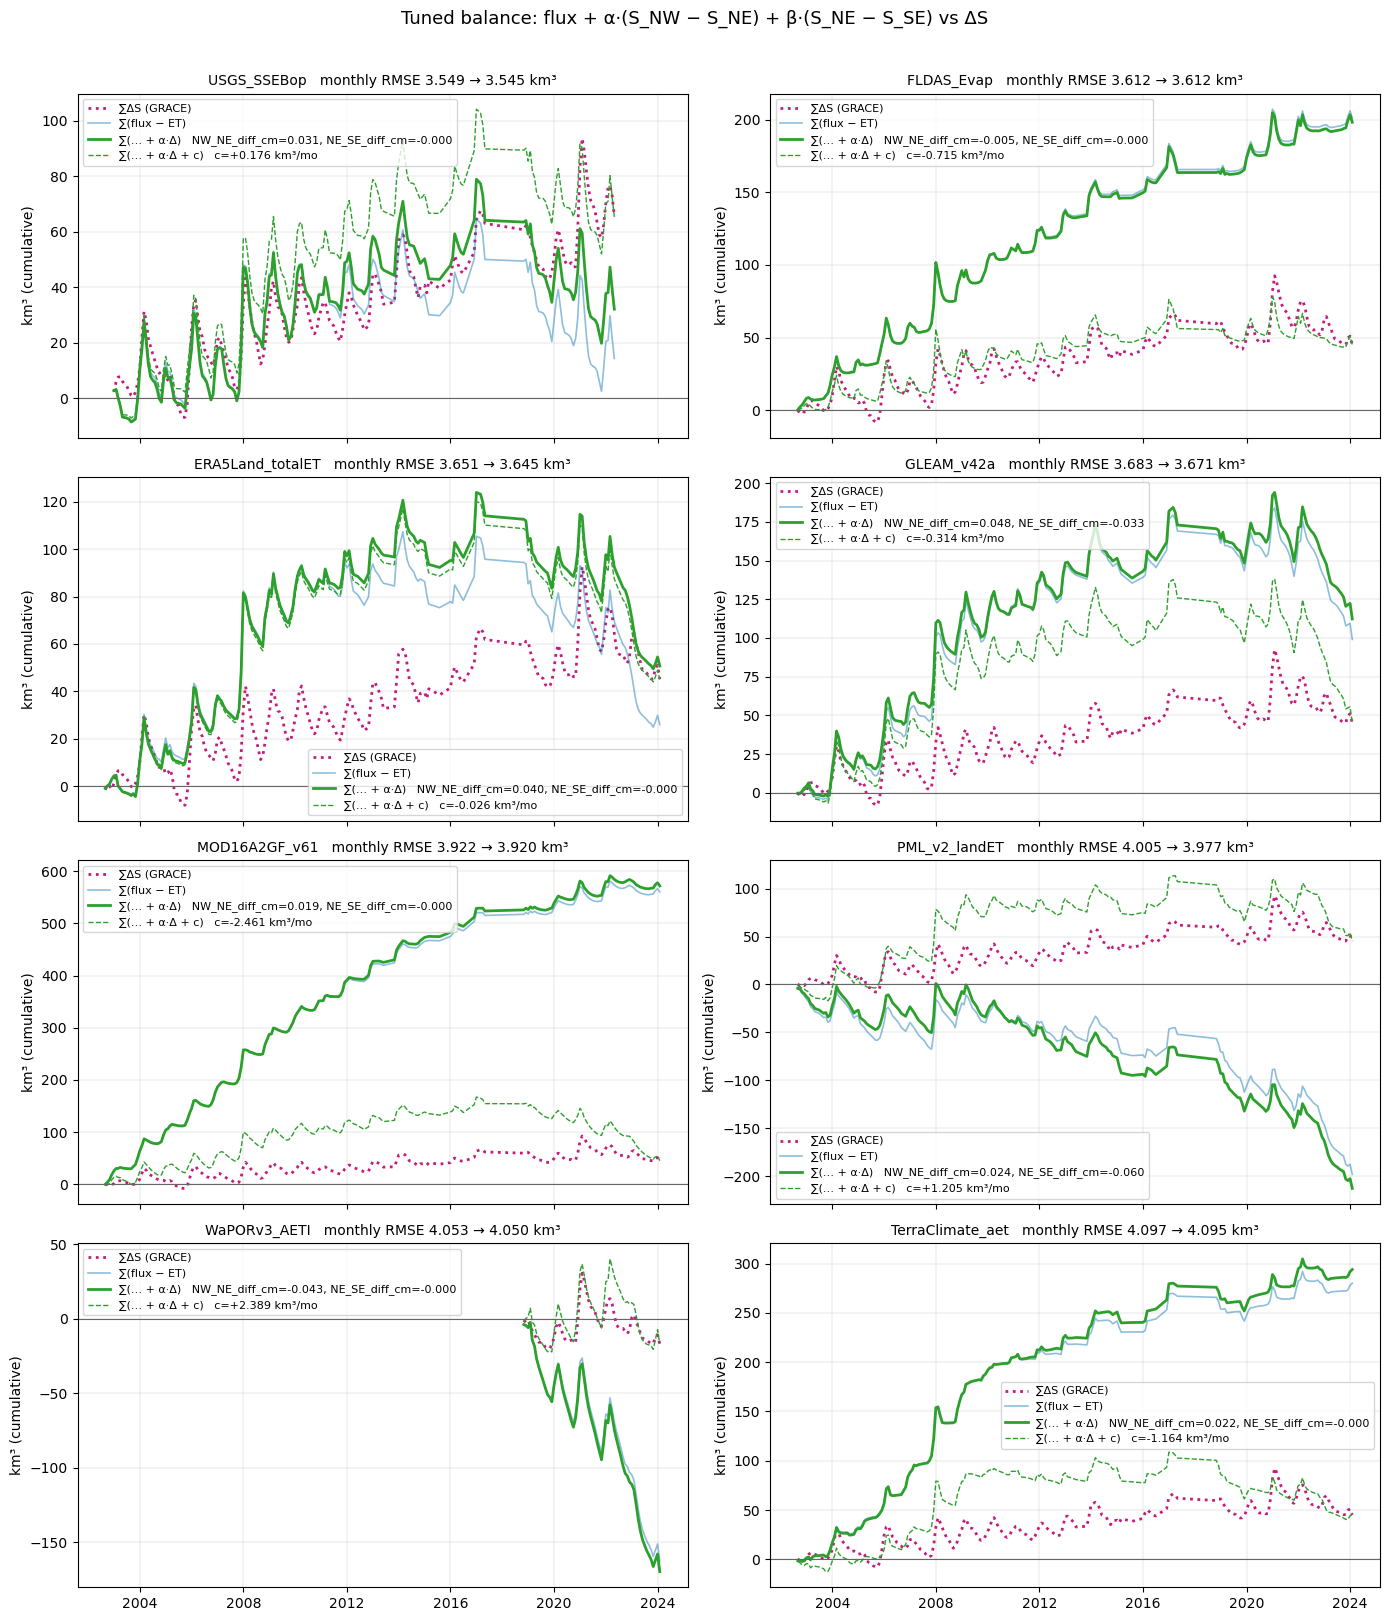

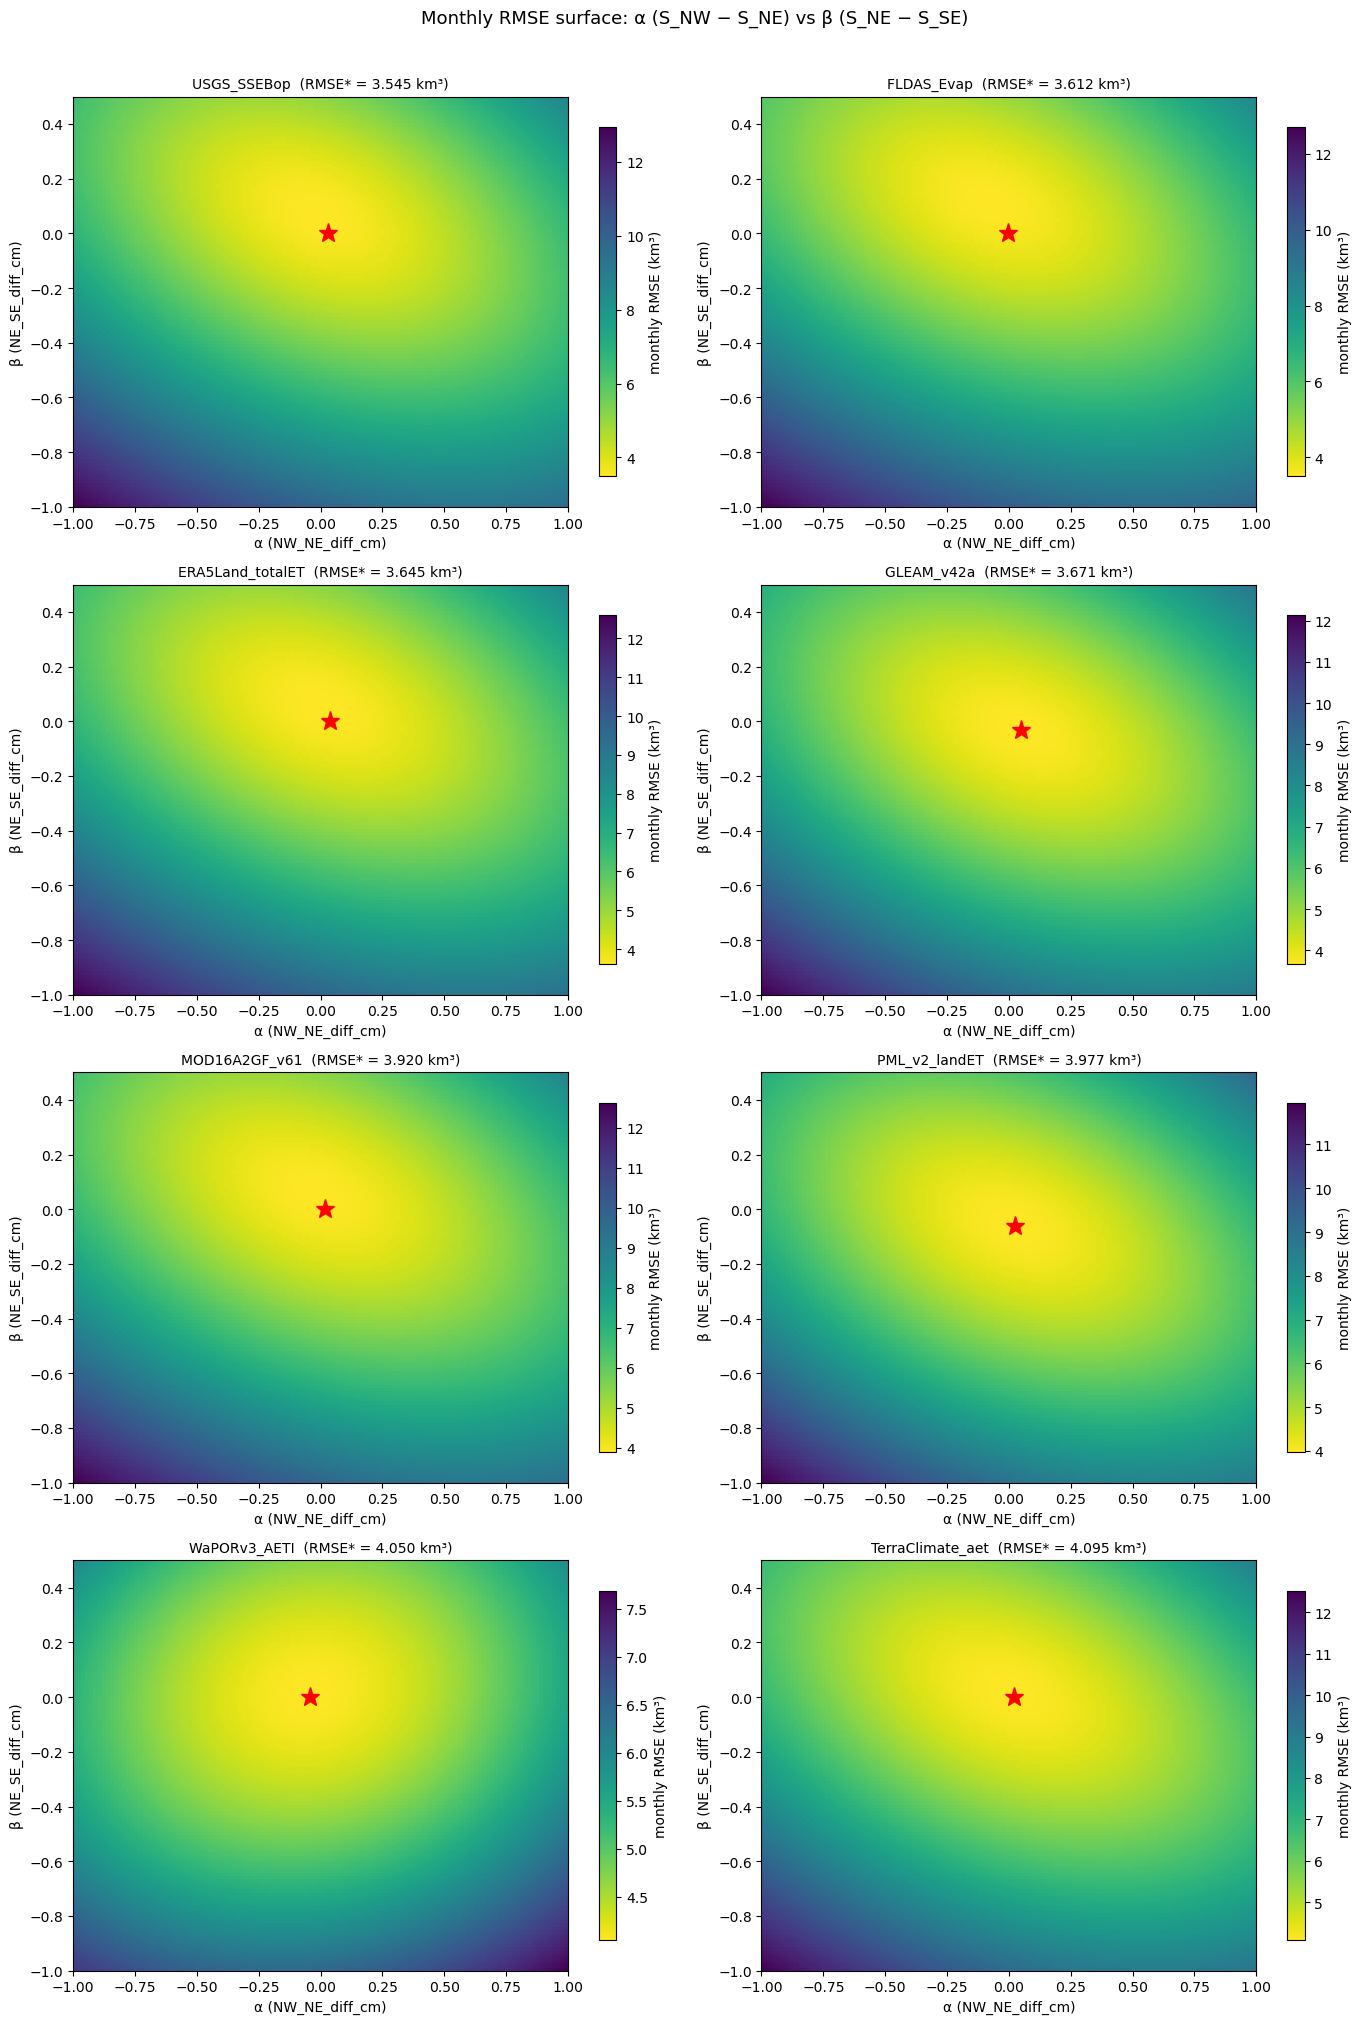

In [ ]:
results_2p, plot_2p = per_model_fits(bal, ["NW_NE_diff_cm", "NE_SE_diff_cm"], bounds=([-np.inf, -np.inf], [np.inf, 0]))
summarize_fits(results_2p, "2-parameter: α × (S_NW − S_NE) + β × (S_NE − S_SE), β ≤ 0")
bp.plot_tuned_cumulative(results_2p, plot_2p, f"Tuned balance: flux + α·(S_NW − S_NE) + β·(S_NE − S_SE) vs ΔS",
                         save=FIG_DIR / "tuned_2param_cumulative.png"); plt.show()
bp.plot_rmse_heatmap(bal, results_2p, "NW_NE_diff_cm", "NE_SE_diff_cm", title=f"Monthly RMSE surface: α (S_NW − S_NE) vs β (S_NE − S_SE)",
                     save=FIG_DIR / "rmse_2d_heatmap.png"); plt.show()

## 11 — Save outputs

In [ ]:
write_outputs(bal, FIG_DIR, GEOM_TAG, USE_BLOCKS, qin=q_mohembo)
results_1p.to_csv(FIG_DIR / "lateral_flux_1p.csv", index=False)
results_2p.to_csv(FIG_DIR / "lateral_flux_2p.csv", index=False)

Outputs written to /Users/octaviacrompton/Projects/Okavango-water-balance/figures/ET comparison/grace_1block_ne
